# Poisson Neural Likelihood Term
Validate the neural likelihoods estimating the poisson term. The neural likelihoods were trained using `nde_poisson.py`

In [1]:
import numpy as np 
from tqdm import tqdm

In [2]:
import torch
import tarp 
from mira_score import mira

In [3]:
from px2cosmo import fm as FM
from px2cosmo import util as UT

In [4]:
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

## construct test data

In [5]:
Nmocks = 2000
test_omegas = np.array([
    np.random.uniform(-1.8, -1.5, size=Nmocks), 
    np.random.uniform(-1.8, -1.2, size=Nmocks),
    np.random.uniform(-0.4, 0, size=Nmocks), 
    np.random.uniform(-22., -18., size=Nmocks), 
    np.random.uniform(1, 10, size=Nmocks) * 1e-3
]).T

test_Ns_z14, test_Ns_z11, test_Ns_z9 = [], [], [] 
for i in tqdm(range(Nmocks)): 
    # forward model 
    mock0 = FM.forwardmodel(test_omegas[i,:-1], name='z14', phi_amp=test_omegas[i,-1])
    mock1 = FM.forwardmodel(test_omegas[i,:-1], name='z11', phi_amp=test_omegas[i,-1])
    mock2 = FM.forwardmodel(test_omegas[i,:-1], name='z9', phi_amp=test_omegas[i,-1])

    test_Ns_z14.append(mock0.shape[0])
    test_Ns_z11.append(mock1.shape[0])
    test_Ns_z9.append(mock2.shape[0])


test_Ns_z14 = np.array(test_Ns_z14)
test_Ns_z11 = np.array(test_Ns_z11)
test_Ns_z9 = np.array(test_Ns_z9)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [06:06<00:00,  5.45it/s]


## load normalizing flow that estimate $p(\omega|N, S)$ for the $z=7, 9, 11$ samples

In [28]:
#p_omegat_log1pN_z14 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/q_omegat_log1pN_z14/q_omegat_log1pN_z14.28.pt', weights_only=False)
p_omegat_log1pN_z14 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/q_omegat_log1pN_z14/q_omegat_log1pN_z14.27.pt', weights_only=False)
p_omegat_log1pN_z11 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z11/q_omegat_log1pN_z11.30.pt', weights_only=False)
p_omegat_log1pN_z9 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z9/q_omegat_log1pN_z9.34.pt', weights_only=False)

## test the flows

In [7]:
bounds = np.array([[-1.8, -1.5], [-1.8, -1.2], [-0.4, 0.], [-22., -18.], [1e-3, 1e-2]])
test_omega_t = UT.inv_cdf_transform(test_omegas, bounds.T)

In [8]:
_test_log1pNs_z14 = torch.tensor(np.log1p(test_Ns_z14).astype(np.float32)[:,None])#.to('mps')
_test_log1pNs_z11 = torch.tensor(np.log1p(test_Ns_z11).astype(np.float32)[:,None]).to('mps')
_test_log1pNs_z9  = torch.tensor(np.log1p(test_Ns_z9).astype(np.float32)[:,None]).to('mps')

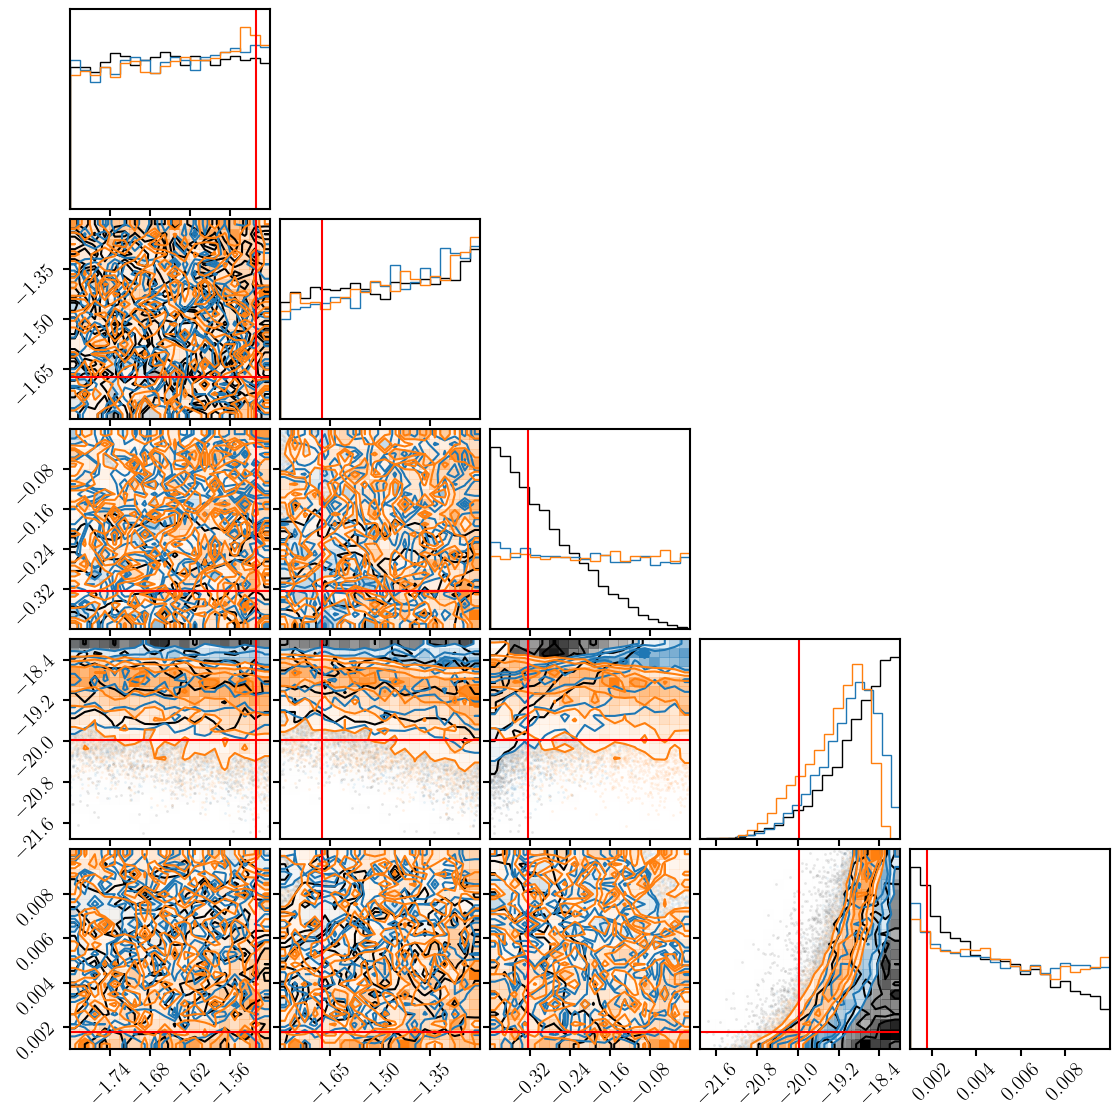

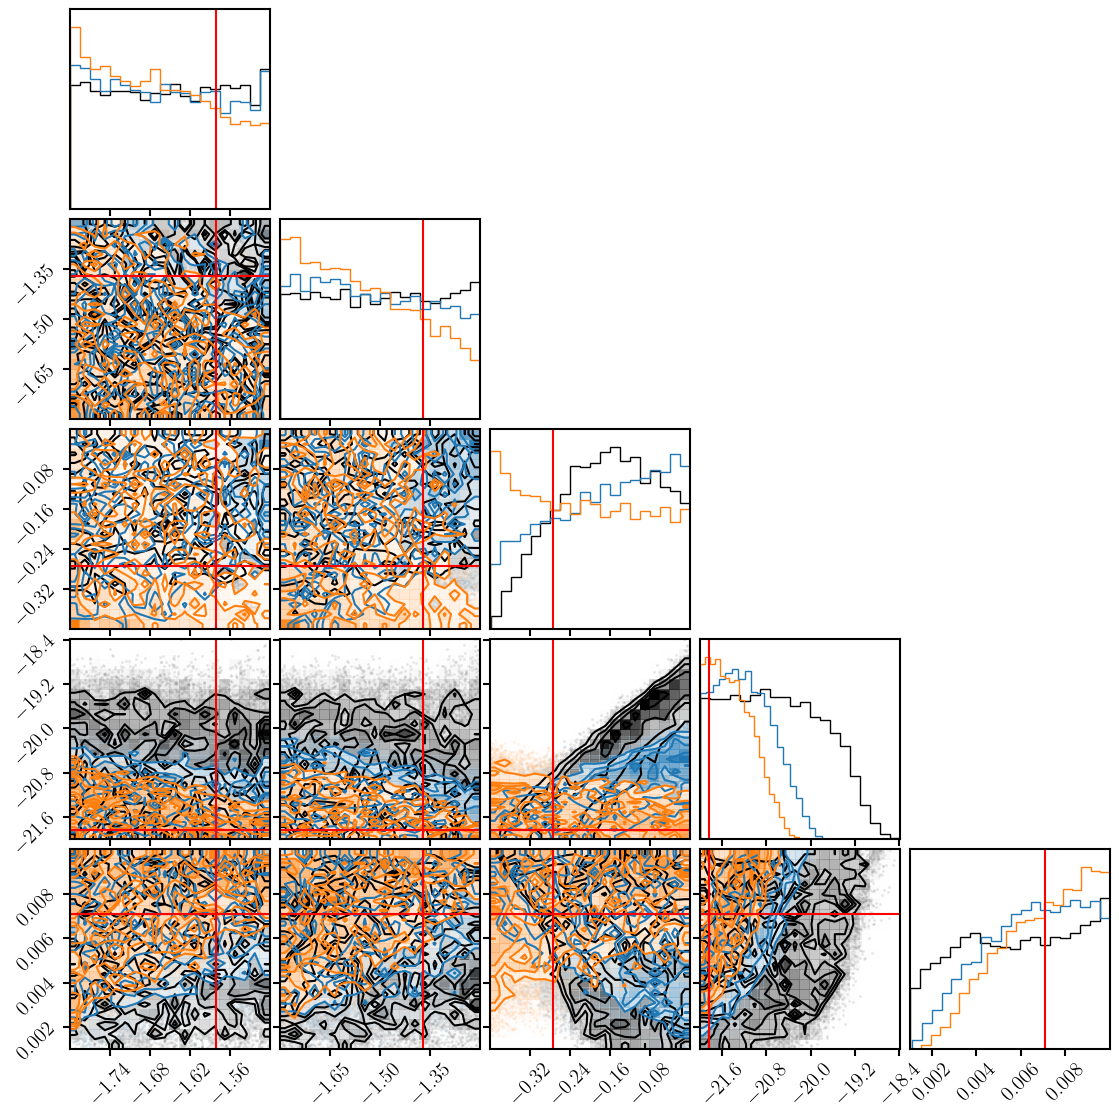

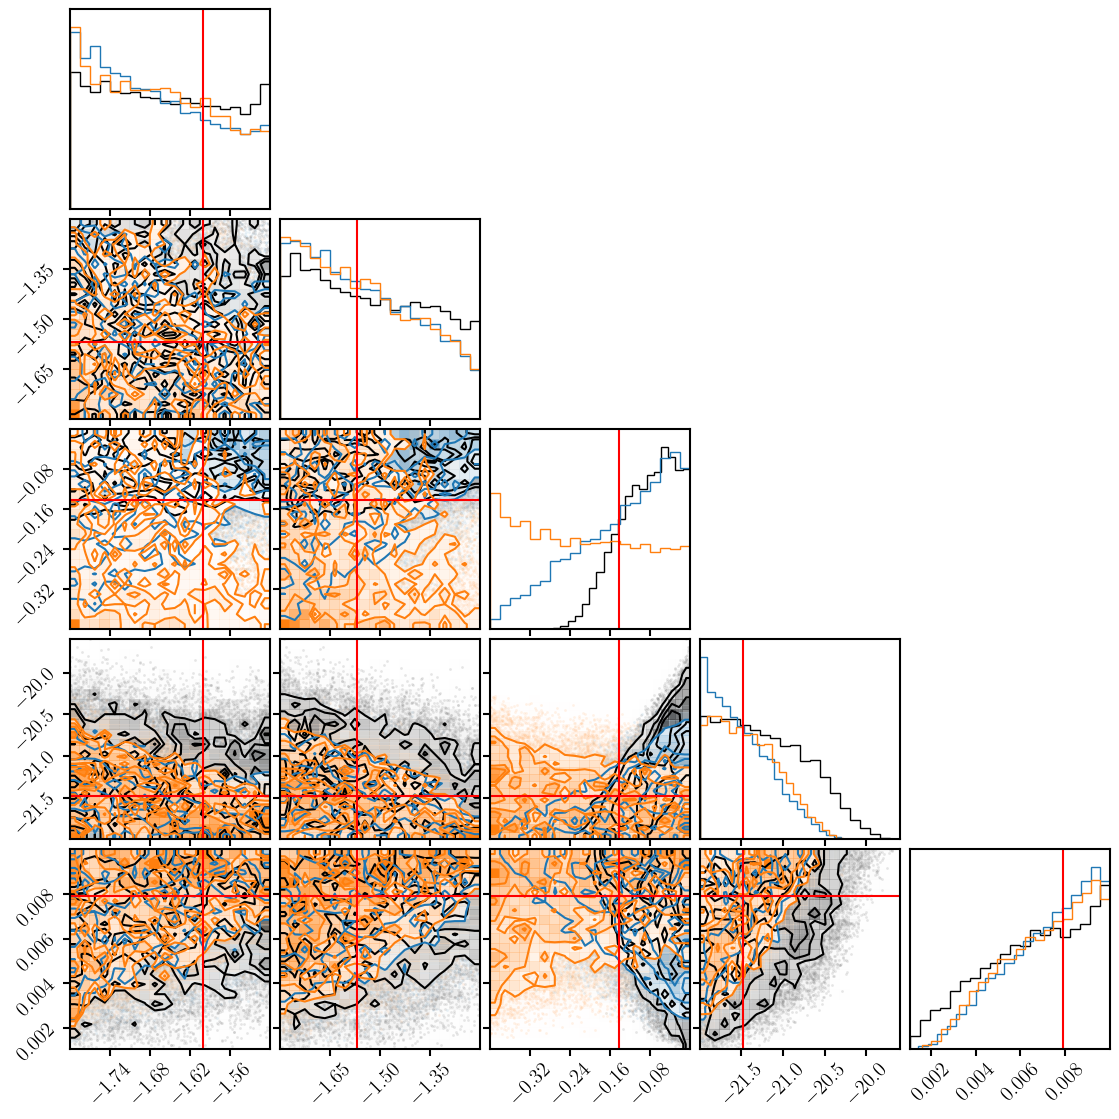

In [9]:
for i in range(3):
    _samples_t = p_omegat_log1pN_z14.sample((10000,), x=_test_log1pNs_z14[i], show_progress_bars=False).cpu().numpy()
    _samples = UT.cdf_transform(_samples_t, bounds.T)
    fig = DFM.corner(_samples, color='k')

    _samples_t = p_omegat_log1pN_z11.sample((10000,), x=_test_log1pNs_z11[i], show_progress_bars=False).cpu().numpy()
    _samples = UT.cdf_transform(_samples_t, bounds.T)
    fig = DFM.corner(_samples, color='C0', fig=fig)
    
    _samples_t = p_omegat_log1pN_z9.sample((10000,), x=_test_log1pNs_z9[i], show_progress_bars=False).cpu().numpy()
    _samples = UT.cdf_transform(_samples_t, bounds.T)
    fig = DFM.corner(_samples, color='C1', fig=fig)
    
    DFM.overplot_lines(fig, test_omegas[i], color='r')
    plt.show()

validation using TARP

In [29]:
test_samples_t_z14 = p_omegat_log1pN_z14.sample_batched((1000,), x=_test_log1pNs_z14, show_progress_bars=False)
test_samples_t_z11 = p_omegat_log1pN_z11.sample_batched((1000,), x=_test_log1pNs_z11, show_progress_bars=False)
test_samples_t_z9 = p_omegat_log1pN_z9.sample_batched((1000,), x=_test_log1pNs_z9, show_progress_bars=False)

In [30]:
test_samples_z14 = UT.cdf_transform(test_samples_t_z14.cpu().numpy(), bounds.T)
test_samples_z11 = UT.cdf_transform(test_samples_t_z11.cpu().numpy(), bounds.T)
test_samples_z9 = UT.cdf_transform(test_samples_t_z9.cpu().numpy(), bounds.T)

In [31]:
ecp_z14, alpha_z14 = tarp.get_tarp_coverage(test_samples_z14, test_omegas)
ecp_z11, alpha_z11 = tarp.get_tarp_coverage(test_samples_z11, test_omegas)
ecp_z9, alpha_z9 = tarp.get_tarp_coverage(test_samples_z9, test_omegas)

In [36]:
L = Nmocks
mean_score_z14, std_score_z14 = mira(torch.tensor(test_omegas.astype(np.float32)), torch.tensor(test_samples_z14[None,:].astype(np.float32)).permute(0, 2, 1, 3), num_runs=100)
mean_score_z11, std_score_z11 = mira(torch.tensor(test_omegas.astype(np.float32)), torch.tensor(test_samples_z11[None,:].astype(np.float32)).permute(0, 2, 1, 3), num_runs=100)
mean_score_z9, std_score_z9 = mira(torch.tensor(test_omegas.astype(np.float32)), torch.tensor(test_samples_z9[None,:].astype(np.float32)).permute(0, 2, 1, 3), num_runs=100)

Mira MC runs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 199.69it/s]


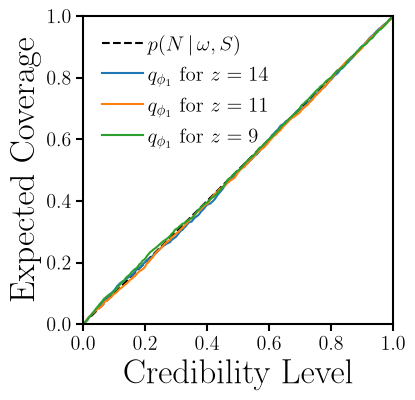

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label=r'$p(N\,|\,\omega,S)$')
ax.plot(alpha_z14, ecp_z14, label=r'$q_{\phi_1}$ for $z=14$')
ax.plot(alpha_z11, ecp_z11, label=r'$q_{\phi_1}$ for $z=11$')
ax.plot(alpha_z9, ecp_z9, label=r'$q_{\phi_1}$ for $z=9$')
ax.legend(fontsize=15, handletextpad=0.2)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0, 1)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0, 1)
fig.savefig('poisson_tarp.pdf', bbox_inches='tight') 

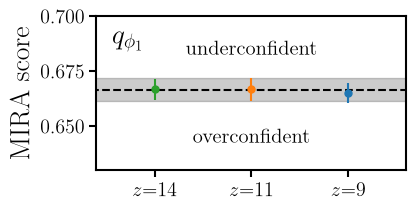

In [40]:
fig = plt.figure(figsize=(4,2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.], [2/3+np.sqrt(1/18/L), 2/3+np.sqrt(1/18/L)], [2/3-np.sqrt(1/18/L), 2/3-np.sqrt(1/18/L)], edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')

sub.errorbar([0.25], [mean_score_z14.item()], yerr=[std_score_z14.item()], c='C2', fmt='o', markersize=5)
sub.errorbar([0.50], [mean_score_z11.item()], yerr=[std_score_z11.item()], c='C1', fmt='o', markersize=5)
sub.errorbar([0.75], [mean_score_z9.item()], yerr=[std_score_z9.item()], c='C0', fmt='o', markersize=5)

sub.text(0.5, 0.685, 'underconfident', ha='center', va='center', fontsize=15)
sub.text(0.5, 0.645, 'overconfident', ha='center', va='center', fontsize=15)
sub.text(0.05, 0.95, r'$q_{\phi_1}$', fontsize=20, transform=sub.transAxes, ha='left', va='top')

sub.set_xlim(0.1, 0.9)
sub.set_xticks([0.25, 0.5, 0.75])
sub.set_xticklabels(['$z{=}14$', '$z{=}11$', '$z{=}9$'])
sub.set_ylim(0.63, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)
fig.savefig('poisson_mira.pdf', bbox_inches='tight') 